# Environment

In [1]:
import sys
from pathlib import Path
import sqlite3
module_path = Path("../01_Functions_classes_and_variables").resolve()
sys.path.append(str(module_path))

from simulation_data_functions import *
from data_exploration_functions import *

import matplotlib.pyplot as plt
from spreg import ML_Lag
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML

from esda.moran import Moran

from sklearn.ensemble import RandomForestRegressor
from causalml.inference.meta import BaseSRegressor
from econml.dml import DML, LinearDML, SparseLinearDML, CausalForestDML
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import PolynomialFeatures

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

# Simulating data

## Single df

### Creating

In [52]:
gdf_output = return_spatial_geo_df(n_x = 30,  
    n_y = 20,    
    spacing = 100, 

    treated_scope_x_start = 10,
    treated_scope_x_end = 20,
    treated_scope_y_start = 7,
    treated_scope_y_end = 13,

    ATT_target = 1.5,

    y_spatial_autocorelation_scope_x_start = 3,
    y_spatial_autocorelation_scope_x_end = 25,
    y_spatial_autocorelation_scope_y_start = 4,
    y_spatial_autocorelation_scope_y_end = 11,

    rho = 0.15,

    spatial_confounder_scope_x_start = 12,
    spatial_confounder_scope_x_end = 28,
    spatial_confounder_scope_y_start = 2,
    spatial_confounder_scope_y_end = 18,
    

    lambda_cs = 0.2,
    max_treatment_spillover_distance = 400,
    understimated_treatment_spillover_distance=300,
    overestimated_treatment_spillover_distance=500,
    
    logistic_distance_decay = True,

    nonspatial_confounders_contribution_to_Y=1.0,
    spatial_confounder_contribution_to_Y=0.7,
    
    epsilon_distribution_mean = 0.025,
    epsilon_distribution_standard_error = 0.2)

In [45]:
gdf_output.isna().any().any()

np.False_

In [68]:
gdf_output.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [60]:
gdf_output[gdf_output['ODR_1'] == 1][['tau',
 'tau_base']]

,tau,tau_base
187,1.342329,1.452514
188,0.749376,0.810888
189,0.710814,0.769161
190,1.683092,1.821249
191,0.689712,0.746327
192,0.834185,0.902659
193,1.528715,1.654200
206,1.427888,1.545096
214,1.170197,1.266252
226,0.620089,0.670989


In [46]:
gdf_output[gdf_output['T']==1][['unit_id', 'Y_dep_var',
    'T','ODR_1',
    'ODR_2',
    'ODR_3',
    'ODR_4', 'Cont_T_N',]]

,unit_id,Y_dep_var,T,ODR_1,ODR_2,ODR_3,ODR_4,Cont_T_N
207,1207,1.806541,1,0,0,0,0,0.0
208,1208,0.162360,1,0,0,0,0,0.0
209,1209,2.188731,1,0,0,0,0,0.0
210,1210,3.515899,1,0,0,0,0,0.0
211,1211,0.951125,1,0,0,0,0,0.0
...,...,...,...,...,...,...,...,...
409,1409,0.751381,1,0,0,0,0,0.0
410,1410,4.648886,1,0,0,0,0,0.0
411,1411,0.382339,1,0,0,0,0,0.0
412,1412,0.727270,1,0,0,0,0,0.0


In [47]:
gdf_output.columns.tolist()

['unit_id',
 'geometry',
 'x',
 'y',
 'T',
 'propensity',
 'T_tot',
 'T_tot_cat',
 'T_tot_cat_underestim',
 'T_tot_cat_overerestim',
 'ODR_1',
 'ODR_2',
 'ODR_3',
 'ODR_4',
 'ODR_5',
 'Cont_T_N',
 'C1',
 'C2',
 'C3',
 'Cs',
 'tau',
 'tau_base',
 'spill',
 'distance_to_treatment',
 'decay',
 'Y_dep_var',
 'Y_dep_var_ns']

#### Numerical checks

In [7]:
gdf_output[gdf_output['ODR_4']!=0][['unit_id','geometry', 'T_tot','T_tot_cat','T_tot_cat_underestim','T_tot_cat_overerestim', 'ODR_4']]

,unit_id,geometry,T_tot,T_tot_cat,T_tot_cat_underestim,T_tot_cat_overerestim,ODR_4
127,1127,POINT (600 700),1,treated_outer_ring4,control,treated_outer_ring4,1
128,1128,POINT (600 800),1,treated_outer_ring4,control,treated_outer_ring4,1
129,1129,POINT (600 900),1,treated_outer_ring4,control,treated_outer_ring4,1
130,1130,POINT (600 1000),1,treated_outer_ring4,control,treated_outer_ring4,1
131,1131,POINT (600 1100),1,treated_outer_ring4,control,treated_outer_ring4,1
132,1132,POINT (600 1200),1,treated_outer_ring4,control,treated_outer_ring4,1
133,1133,POINT (600 1300),1,treated_outer_ring4,control,treated_outer_ring4,1
145,1145,POINT (700 500),1,treated_outer_ring4,control,treated_outer_ring4,1
146,1146,POINT (700 600),1,treated_outer_ring4,control,treated_outer_ring4,1
154,1154,POINT (700 1400),1,treated_outer_ring4,control,treated_outer_ring4,1


In [8]:
gdf_output['spill'].unique()

array([0.        , 0.00669285, 0.01774272, 0.0518728 , 0.07585818,
       0.11194084, 0.35659586, 0.5       , 0.8122148 , 0.92414182,
       1.        ])

In [9]:
gdf_output[(gdf_output['T_tot']!=0)
            #&(gdf_output2['T']!=0)
            ]['tau'].mean()

np.float64(0.7424414903341209)

In [10]:
gdf_output[(gdf_output['T_tot']!=0)
            &(gdf_output['T']!=0)
            ]['tau'].mean()

np.float64(1.5)

In [11]:
gdf_output[gdf_output['T']==1]

,unit_id,geometry,x,y,T,propensity,T_tot,T_tot_cat,T_tot_cat_underestim,T_tot_cat_overerestim,...,C2,C3,Cs,tau,tau_base,spill,distance_to_treatment,decay,Y_dep_var,Y_dep_var_ns
207,1207,POINT (1000 700),1000,700,1,-0.552352,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-1.287125,0.159008,0.407625,0.886788,0.886788,1.0,0.0,1.0,0.339282,-0.009609
208,1208,POINT (1000 800),1000,800,1,3.235223,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,0.871842,1.298973,-0.345279,2.185068,2.185068,1.0,0.0,1.0,4.895477,4.632974
209,1209,POINT (1000 900),1000,900,1,0.354860,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,1.414335,-1.414216,-0.084551,1.890208,1.890208,1.0,0.0,1.0,2.248603,1.916735
210,1210,POINT (1000 1000),1000,1000,1,-1.009961,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,1.020807,-0.440168,-0.495639,1.926398,1.926398,1.0,0.0,1.0,1.996218,1.919936
211,1211,POINT (1000 1100),1000,1100,1,-3.402471,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,-1.854340,0.066425,-1.250355,0.732115,0.732115,1.0,0.0,1.0,-1.504627,-1.929509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,1489,POINT (2400 900),2400,900,1,0.260081,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,0.447636,-0.899541,-0.555890,1.786559,1.786559,1.0,0.0,1.0,1.688050,1.389234
490,1490,POINT (2400 1000),2400,1000,1,-0.836920,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,0.411684,-2.418425,-0.354490,1.614812,1.614812,1.0,0.0,1.0,0.880939,0.677763
491,1491,POINT (2400 1100),2400,1100,1,0.382849,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,2.679113,-1.039341,-0.881267,1.868573,1.868573,1.0,0.0,1.0,2.949249,2.581873
492,1492,POINT (2400 1200),2400,1200,1,0.445784,1,treated_inner_ring,treated_inner_ring,treated_inner_ring,...,0.118126,-0.297657,0.869117,1.397552,1.397552,1.0,0.0,1.0,1.977966,1.977966


In [12]:
gdf_output.isna().any().any()

np.False_

In [14]:
coords = np.array(list(zip(gdf_output["x"], gdf_output["y"])))

W = DistanceBand(coords, threshold=101, binary=True, silence_warnings=True)
W.transform = "R" 
moran_I_y= Moran(gdf_output['Y_dep_var'], W)
[f'Moran I: {moran_I_y.I:.4f}',  f'p-value simulated: {moran_I_y.p_sim:.4f}']

['Moran I: 0.2167', 'p-value simulated: 0.0010']

#### Visual checks

In [48]:
gdf_output3 = gdf_output.copy()
gdf_output3['spill2'] = gdf_output3['spill'] + 0.5

<Axes: >

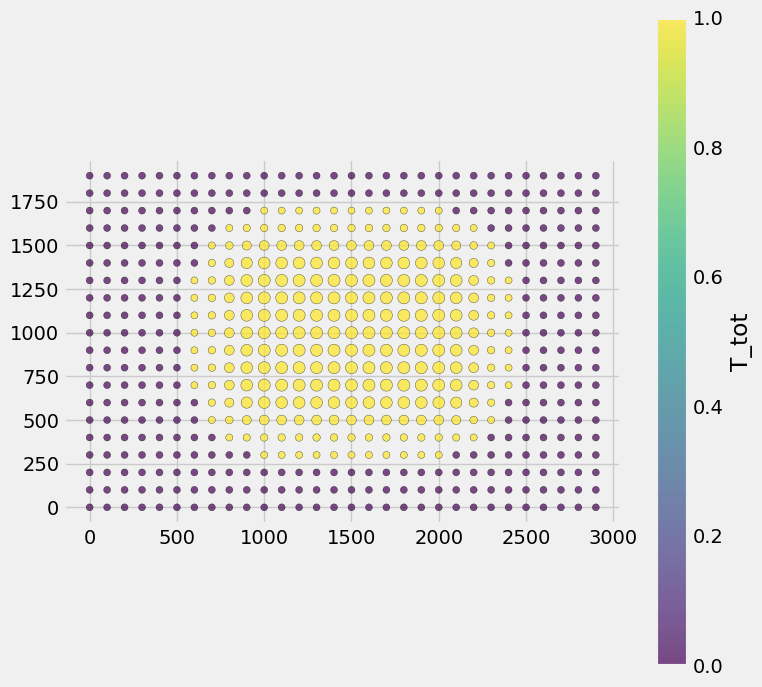

In [93]:
plot_gdf_points(gdf_output3, size_col='spill2',
    color_col='T_tot')

<Axes: >

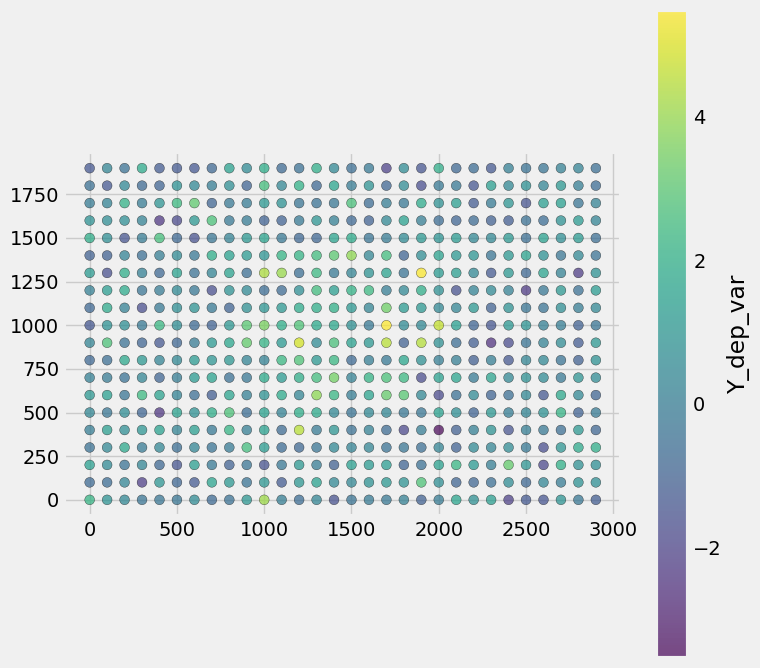

In [51]:
plot_gdf_points(gdf_output, #size_col='Y',
    color_col='Y_dep_var')

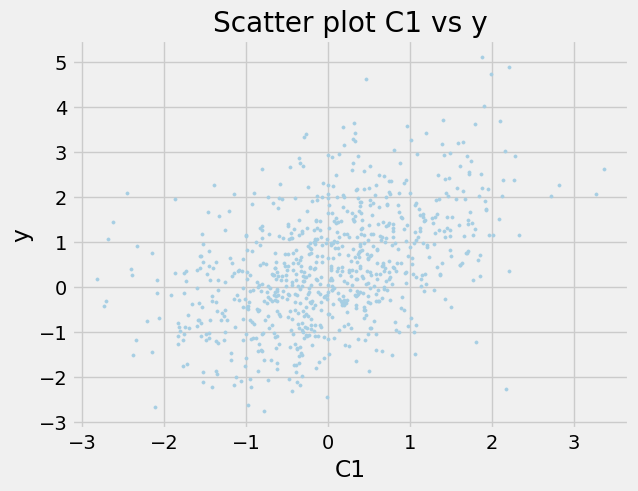

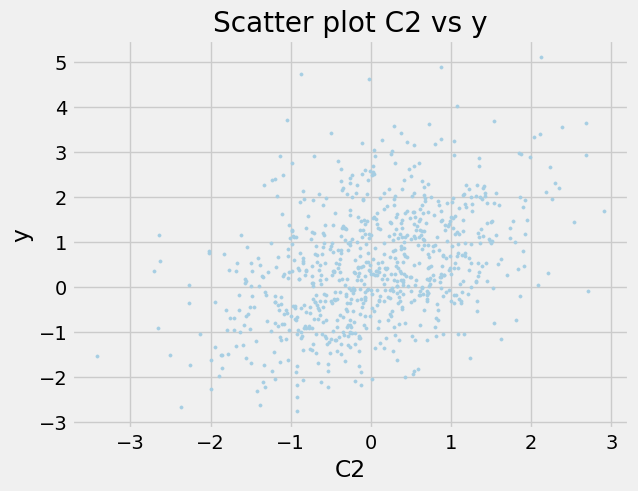

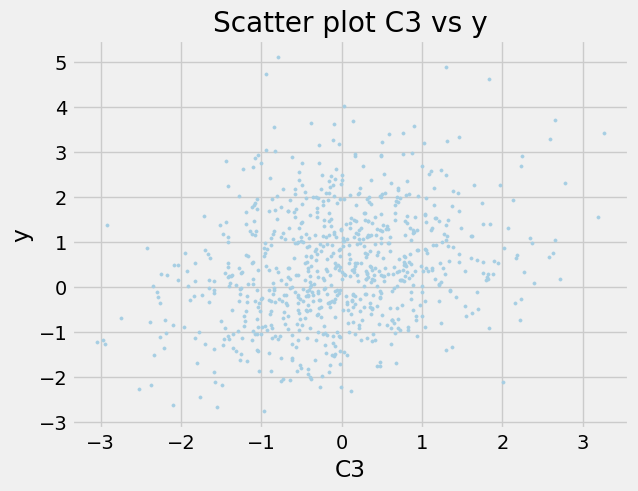

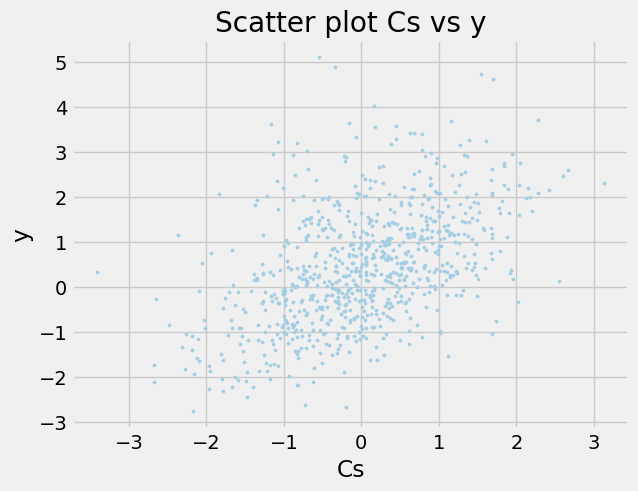

In [20]:
for i in ['C1','C2','C3','Cs']:
    gdf_output.plot.scatter(x=i, y="Y_dep_var", s=5)
    plt.xlabel(i)
    plt.ylabel("y")
    plt.title(f"Scatter plot {i} vs y")
    plt.show()

#### Modelling checks

##### Data

In [23]:
X1 = gdf_output[["C1","C2",
         #"C3","Cs",
         'T'
         ]].values
X = gdf_output[["C1","C2",
         #"C3","Cs"
         ]].values
y = gdf_output["Y_dep_var"].values.reshape(-1,1)
T = gdf_output["T"].values
T_tot = gdf_output["T_tot"].values
Xdf = gdf_output[["C1","C2",'T',
         #"C3","Cs"
         ]]
Xdf2 = gdf_output[["C1","C2",'T_tot',
         #"C3","Cs"
         ]]
X_l = sm.add_constant(Xdf)
X_l2 = sm.add_constant(Xdf2)
y_l = gdf_output["Y_dep_var_ns"]
Y = gdf_output['Y_dep_var'].values

X_logit = sm.add_constant(X)

In [24]:
gdf_output4 = gdf_output.copy()
gdf_output4['treated'] = 'control'
gdf_output4.loc[(gdf_output4['spill'] == 1),'treated'] = 'inner_ring'
gdf_output4.loc[(gdf_output4['spill'] <= 0.924143)& (gdf_output4['spill'] >= 0.812214),'treated'] = 'outer_ring1'
gdf_output4.loc[(gdf_output4['spill'] <= 0.500001)& (gdf_output4['spill'] >= 0.356595),'treated'] = 'outer_ring2'
gdf_output4.loc[(gdf_output4['spill'] <= 0.111942)& (gdf_output4['spill'] >= 0.075857),'treated'] = 'outer_ring3'
gdf_output4.loc[(gdf_output4['spill'] <= 0.017744)& (gdf_output4['spill'] >= 0.006692),'treated'] = 'outer_ring4'
df_encoded = pd.get_dummies(gdf_output4, columns=['treated'], dtype=int)
T_mult = df_encoded[['treated_inner_ring',
    'treated_outer_ring1',
    'treated_outer_ring2',
    'treated_outer_ring3',
    'treated_outer_ring4']].to_numpy()
T_M= gdf_output4['treated'].values
T_M= T_M.astype(str)

##### Logit for T

In [25]:
logit_model = sm.Logit(T, X_logit)
logit_res = logit_model.fit()

print(logit_res.summary())

Optimization terminated successfully.
         Current function value: 0.387860
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  800
Model:                          Logit   Df Residuals:                      797
Method:                           MLE   Df Model:                            2
Date:                Sat, 23 May 2026   Pseudo R-squ.:                0.002305
Time:                        17:39:54   Log-Likelihood:                -310.29
converged:                       True   LL-Null:                       -311.00
Covariance Type:            nonrobust   LLR p-value:                    0.4883
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.8988      0.106    -17.993      0.000      -2.106      -1.692
x1            -0.0344      0.

##### Cross sectional linear difference in differences 

In [26]:
model = sm.OLS(y_l, X_l)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           Y_dep_var_ns   R-squared:                       0.540
Model:                            OLS   Adj. R-squared:                  0.538
Method:                 Least Squares   F-statistic:                     311.6
Date:                Sat, 23 May 2026   Prob (F-statistic):          9.14e-134
Time:                        17:40:02   Log-Likelihood:                -1008.7
No. Observations:                 800   AIC:                             2025.
Df Residuals:                     796   BIC:                             2044.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2277      0.032      7.010      0.0

In [27]:
model = sm.OLS(y_l, X_l2)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           Y_dep_var_ns   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.471
Method:                 Least Squares   F-statistic:                     238.0
Date:                Sat, 23 May 2026   Prob (F-statistic):          3.37e-110
Time:                        17:40:07   Log-Likelihood:                -1063.3
No. Observations:                 800   AIC:                             2135.
Df Residuals:                     796   BIC:                             2153.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1525      0.042      3.672      0.0

##### Cross sectional difference in differences with spatial lag of Y

In [29]:
model_sdm = ML_Lag(
    y,
    X1,
    w=W,              
    slx_lags=1,       
    name_y="Y_dep_var",
    name_x=["C1","C2", 'T'#,"C3","Cs"
            ]
)

print(model_sdm.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG WITH SLX - SPATIAL DURBIN MODEL (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :   Y_dep_var                Number of Observations:         800
Mean dependent var  :      0.4615                Number of Variables   :           8
S.D. dependent var  :      1.2867                Degrees of Freedom    :         792
Pseudo R-squared    :      0.5708
Spatial Pseudo R-squared:  0.5669
Log likelihood      :   -999.2523
Sigma-square ML     :      0.7097                Akaike info criterion :    2014.505
S.E of regression   :      0.8424                Schwarz criterion     :    2051.981

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-----

##### Basic causal forest

###### For T

In [30]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T', 'tau']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T']==1]

,unit_id,geometry,T,tau,tau_cf
207,1207,POINT (1000 700),1,0.886788,0.731274
208,1208,POINT (1000 800),1,2.185068,2.127838
209,1209,POINT (1000 900),1,1.890208,1.746987
210,1210,POINT (1000 1000),1,1.926398,1.551201
211,1211,POINT (1000 1100),1,0.732115,0.176802
...,...,...,...,...,...
489,1489,POINT (2400 900),1,1.786559,1.290891
490,1490,POINT (2400 1000),1,1.614812,1.053897
491,1491,POINT (2400 1100),1,1.868573,1.827665
492,1492,POINT (2400 1200),1,1.397552,1.107523


In [31]:
ci_low_ate, ate, ci_high_ate

(np.float64(1.3648475582247894),
 np.float64(1.3936882210456878),
 np.float64(1.4225288838665862))

In [32]:
gdf_rf_compare[gdf_rf_compare['T']==1]['tau_cf'].mean()

np.float64(1.4278370783433374)

###### For T tot

In [33]:
forest_Y = RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42)
forest_Y.fit(X, Y)

forest_T = RandomForestRegressor(n_estimators=180, max_depth=10, random_state=42)
forest_T.fit(X, T_tot)

cf = CausalForestDML(model_y=forest_Y, model_t=forest_T, random_state=42)
cf.fit(Y, T_tot, X=X)
tau_hat = cf.effect(X)



ate = tau_hat.mean()
se_ate = tau_hat.std(ddof=1) / np.sqrt(len(tau_hat))

ci_low_ate, ci_high_ate = ate - 1.96 * se_ate, ate + 1.96 * se_ate
gdf_rf_compare = gdf_output[['unit_id',	'geometry',	'T_tot', 'tau', 'tau_base']].copy()
gdf_rf_compare['tau_cf'] = tau_hat
gdf_rf_compare[gdf_rf_compare['T_tot']==1]

,unit_id,geometry,T_tot,tau,tau_base,tau_cf
127,1127,POINT (600 700),1,0.008501,1.270116,0.335038
128,1128,POINT (600 800),1,0.007799,1.165236,0.849580
129,1129,POINT (600 900),1,0.002024,0.302471,0.298707
130,1130,POINT (600 1000),1,0.009832,1.468993,0.967359
131,1131,POINT (600 1100),1,0.010973,1.639464,0.756559
...,...,...,...,...,...,...
569,1569,POINT (2800 900),1,0.005664,0.846202,0.351081
570,1570,POINT (2800 1000),1,0.002261,0.337810,0.397494
571,1571,POINT (2800 1100),1,0.001185,0.177081,0.357312
572,1572,POINT (2800 1200),1,0.004871,0.727775,0.518774


#### Multiple T DML

In [34]:
est = LinearDML(model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                model_t=MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100,
                                                                       max_depth=3,
                                                                       min_samples_leaf=20)),
                featurizer=PolynomialFeatures(degree=2, include_bias=False),
                cv=None)


In [35]:
est.fit(Y, T_mult, X=X, 
        #W=W
        )

In [36]:
te_pred = est.const_marginal_effect(X)
te_pred

array([[ 1.28331893,  0.91695495,  0.40403494,  0.27238037, -0.37372067],
       [ 1.94191263,  0.76514824,  0.60820941,  0.0741591 , -0.29931581],
       [ 1.75760199,  0.36915044,  0.83953586,  0.14597127, -0.55336391],
       ...,
       [ 1.69849892,  0.77113899,  0.38430494, -0.15499165, -0.02649616],
       [ 1.77273971,  0.88420222,  0.55108007,  0.16158725, -0.22111286],
       [ 0.95909301,  0.71502882,  0.33382732,  0.1169796 , -0.40111587]],
      shape=(800, 5))

In [37]:
est2 = CausalForestDML(model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, min_samples_leaf=20),
                       model_t=MultiOutputRegressor(GradientBoostingRegressor(n_estimators=100,
                                                                              max_depth=3,
                                                                              min_samples_leaf=20)),
                       cv=None,
                       criterion='mse', n_estimators=1000,
                       min_samples_leaf=10,
                       min_impurity_decrease=0.001,
                       random_state=123)

est2.tune(Y, T_mult, X=X, 
          #W=W
          )
est2.fit(Y, T_mult, X=X, 
         #W=W
         )

In [38]:
te_pred2 = est2.const_marginal_effect(X)
te_pred2

array([[ 1.57900683e+00,  7.73448182e-01,  4.40691316e-01,
         1.61847566e-01, -5.70969182e-02],
       [ 1.75460912e+00,  7.69642483e-01,  6.00500818e-01,
         2.47847666e-02, -4.72470062e-04],
       [ 1.89873509e+00,  5.23952298e-01,  5.90611230e-01,
         1.59900813e-01,  3.82201995e-03],
       ...,
       [ 1.68981711e+00,  7.20241561e-01,  4.11471708e-01,
         1.47598131e-01,  1.42316831e-02],
       [ 1.62094671e+00,  7.48788408e-01,  4.45777929e-01,
         1.54416916e-01, -7.06970552e-02],
       [ 1.56776623e+00,  7.15614109e-01,  3.77503465e-01,
         4.66544405e-02,  3.88876776e-02]], shape=(800, 5))

#### S learner with multiple treatments

In [ ]:
RF_s_learner = BaseSRegressor(RandomForestRegressor(n_estimators=160, max_depth=10, random_state=42), control_name = 'control')
ate, lb, ub = RF_s_learner.estimate_ate(X, T_M, Y, return_ci = True)
ite = RF_s_learner.fit_predict(X, T_M, Y)
ITE_df = pd.DataFrame(ite).rename(columns = {0:'inner_ring', 1:'outer_ring1', 
                                             2:'outer_ring2', 3:'outer_ring3',
                                             4:'outer_ring4'})
ITE_df['treated'] = T_M
ITE_df['ITE_real'] = gdf_output4['tau']
ITE_df['Y'] = Y

In [40]:
ate, lb, ub

(array([ 1.61239924,  0.53519423,  0.29631482,  0.0334366 , -0.07003596]),
 array([ 1.51569454,  0.41167175,  0.18561945, -0.08341318, -0.18265418]),
 array([1.70910394, 0.65871671, 0.40701019, 0.15028638, 0.04258225]))

In [41]:
ITE_df['treated'].unique()

array(['control', 'outer_ring4', 'outer_ring3', 'outer_ring2',
       'outer_ring1', 'inner_ring'], dtype=object)

In [42]:
for i in ['outer_ring4', 'outer_ring3', 'outer_ring2', 'outer_ring1', 'inner_ring']:
    series_of_interest = ITE_df[ITE_df['treated']==i][i]
    att = series_of_interest.mean()
    se_att = (series_of_interest).std(ddof=1) / np.sqrt(len(series_of_interest))
    ci_low_att, ci_high_att = att - 1.96 * se_att, att + 1.96 * se_att
    print(i, 
          [ci_low_att, att, ci_high_att], 
          ITE_df[ITE_df['treated']==i]['ITE_real'].mean())

outer_ring4 [np.float64(-0.09810521383753511), np.float64(-0.05235260923043518), np.float64(-0.006600004623335251)] 0.008176136859833207
outer_ring3 [np.float64(-0.007664965122710678), np.float64(0.03827053443552343), np.float64(0.08420603399375753)] 0.08899957790049982
outer_ring2 [np.float64(0.17068669624447633), np.float64(0.2949778165203554), np.float64(0.41926893679623445)] 0.4715643220037712
outer_ring1 [np.float64(0.41235879017146365), np.float64(0.5437672528956266), np.float64(0.6751757156197895)] 0.9433882222900442
inner_ring [np.float64(1.4024204582502602), np.float64(1.547112734854792), np.float64(1.6918050114593237)] 1.5


In [43]:
ITE_df

,inner_ring,outer_ring1,outer_ring2,outer_ring3,outer_ring4,treated,ITE_real,Y
0,1.676412,1.129288,0.166682,0.144574,-0.067859,control,0.0,-0.771925
1,2.000295,0.996927,0.994719,-0.016307,0.031434,control,0.0,0.944392
2,1.130826,0.444545,0.067684,-0.023060,-0.002332,control,0.0,2.694748
3,1.730176,1.268719,1.351140,-0.104192,-0.262733,control,0.0,0.801908
4,1.387960,0.771731,-0.005867,0.143471,-0.059396,control,0.0,-0.729065
...,...,...,...,...,...,...,...,...
795,1.349848,1.110716,0.179018,-0.010801,-0.182047,control,0.0,-0.633318
796,1.675819,0.549932,0.250167,-0.146219,0.029242,control,0.0,-0.116076
797,2.069142,0.140688,-0.115077,0.065644,-0.030947,control,0.0,-0.297577
798,1.369107,0.624101,0.181791,0.032461,-0.068760,control,0.0,0.278195


In [44]:
ITE_df[ITE_df['treated']=='inner_ring']['ITE_real'].mean()

np.float64(1.5)

## Generating multiple df for simulations

### Data generation

#### Single test output

In [ ]:
# gdf_output = return_spatial_geo_df(n_x = 40,  
#     n_y = 20,    
#     spacing = 100, 

#     treated_scope_x_start = 10,
#     treated_scope_x_end = 24,
#     treated_scope_y_start = 7,
#     treated_scope_y_end = 13,

#     ATT_target = 1.5,

#     y_spatial_autocorelation_scope_x_start = 3,
#     y_spatial_autocorelation_scope_x_end = 25,
#     y_spatial_autocorelation_scope_y_start = 4,
#     y_spatial_autocorelation_scope_y_end = 11,

#     rho = 0.15,

#     spatial_confounder_scope_x_start = 12,
#     spatial_confounder_scope_x_end = 32,
#     spatial_confounder_scope_y_start = 2,
#     spatial_confounder_scope_y_end = 18,
    

#     lambda_cs = 0.2,
#     max_treatment_spillover_distance = 400,
#     understimated_treatment_spillover_distance=300,
#     overestimated_treatment_spillover_distance=500,
    
#     logistic_distance_decay = True,

#     nonspatial_confounders_contribution_to_Y=1.0,
#     spatial_confounder_contribution_to_Y=0.7,
    
#     epsilon_distribution_mean = 0.025,
#     epsilon_distribution_standard_error = 0.2)

#### Initial 15 samples for spatial predictors

In [ ]:
# list_of_rhos = []
# for i in np.arange(0.75, 0.000, -0.05):
#     list_of_rhos.append(i)
# len(list_of_rhos)

15

In [ ]:
# dict_of_output_gdf = {}
# for i in list_of_rhos:
#     single_gdf_output = return_spatial_geo_df(n_x = 40,  
#         n_y = 20,    
#         spacing = 100, 

#         treated_scope_x_start = 10,
#         treated_scope_x_end = 24,
#         treated_scope_y_start = 7,
#         treated_scope_y_end = 13,

#         ATT_target = 1.5,

#         y_spatial_autocorelation_scope_x_start = 3,
#         y_spatial_autocorelation_scope_x_end = 25,
#         y_spatial_autocorelation_scope_y_start = 4,
#         y_spatial_autocorelation_scope_y_end = 11,

#         rho = 0.15,

#         spatial_confounder_scope_x_start = 12,
#         spatial_confounder_scope_x_end = 32,
#         spatial_confounder_scope_y_start = 2,
#         spatial_confounder_scope_y_end = 18,
        

#         lambda_cs = 0.2,
#         max_treatment_spillover_distance = 400,
#         understimated_treatment_spillover_distance=300,
#         overestimated_treatment_spillover_distance=500,
        
#         logistic_distance_decay = True,

#         nonspatial_confounders_contribution_to_Y=1.0,
#         spatial_confounder_contribution_to_Y=0.7,
        
#         epsilon_distribution_mean = 0.025,
#         epsilon_distribution_standard_error = 0.2)
#     single_gdf_output2 = single_gdf_output.drop(columns = ['y', 'x']).copy()
#     dict_of_output_gdf[f'gdf_rho_0_{str(i)[2:5]}'] = single_gdf_output2

In [ ]:
#len(['gdf_rho_0_75', 'gdf_rho_0_7', 'gdf_rho_0_649', 'gdf_rho_0_599', 'gdf_rho_0_549', 'gdf_rho_0_499', 'gdf_rho_0_449', 'gdf_rho_0_399', 'gdf_rho_0_349', 'gdf_rho_0_299', 'gdf_rho_0_249', 'gdf_rho_0_199', 'gdf_rho_0_149', 'gdf_rho_0_099', 'gdf_rho_0_049'])

15

#### 16 additional samples for spatial predictors

In [3]:
# list_of_rhos = []
# for i in np.arange(0.775, 0.000, -0.05):
#     list_of_rhos.append(i)
# len(list_of_rhos)

16

In [ ]:
# dict_of_output_gdf = {}
# for i in list_of_rhos:
#     single_gdf_output = return_spatial_geo_df(n_x = 40,  
#         n_y = 20,    
#         spacing = 100, 

#         treated_scope_x_start = 10,
#         treated_scope_x_end = 24,
#         treated_scope_y_start = 7,
#         treated_scope_y_end = 13,

#         ATT_target = 1.5,

#         y_spatial_autocorelation_scope_x_start = 3,
#         y_spatial_autocorelation_scope_x_end = 25,
#         y_spatial_autocorelation_scope_y_start = 4,
#         y_spatial_autocorelation_scope_y_end = 11,

#         rho = 0.15,

#         spatial_confounder_scope_x_start = 12,
#         spatial_confounder_scope_x_end = 32,
#         spatial_confounder_scope_y_start = 2,
#         spatial_confounder_scope_y_end = 18,
        

#         lambda_cs = 0.2,
#         max_treatment_spillover_distance = 400,
#         understimated_treatment_spillover_distance=300,
#         overestimated_treatment_spillover_distance=500,
        
#         logistic_distance_decay = True,

#         nonspatial_confounders_contribution_to_Y=1.0,
#         spatial_confounder_contribution_to_Y=0.7,
        
#         epsilon_distribution_mean = 0.025,
#         epsilon_distribution_standard_error = 0.2)
#     single_gdf_output2 = single_gdf_output.drop(columns = ['y', 'x']).copy()
#     dict_of_output_gdf[f'gdf_rho_0_{str(i)[2:5]}'] = single_gdf_output2

In [6]:
#dict_of_output_gdf.keys()

dict_keys(['gdf_rho_0_775', 'gdf_rho_0_725', 'gdf_rho_0_674', 'gdf_rho_0_624', 'gdf_rho_0_574', 'gdf_rho_0_524', 'gdf_rho_0_474', 'gdf_rho_0_424', 'gdf_rho_0_374', 'gdf_rho_0_324', 'gdf_rho_0_274', 'gdf_rho_0_224', 'gdf_rho_0_174', 'gdf_rho_0_124', 'gdf_rho_0_074', 'gdf_rho_0_024'])

#### 999 samples without spatial predictors

In [53]:
list_of_rhos2 = []
for i in range(1, 1000, 1):
    list_of_rhos2.append(i/1000)
len(list_of_rhos2)

999

In [ ]:
dict_of_output_gdf = {}
for i in list_of_rhos2:
    single_gdf_output = return_spatial_geo_df(n_x = 40,  
        n_y = 20,    
        spacing = 100, 

        treated_scope_x_start = 10,
        treated_scope_x_end = 24,
        treated_scope_y_start = 7,
        treated_scope_y_end = 13,

        ATT_target = 1.5,

        y_spatial_autocorelation_scope_x_start = 3,
        y_spatial_autocorelation_scope_x_end = 25,
        y_spatial_autocorelation_scope_y_start = 4,
        y_spatial_autocorelation_scope_y_end = 11,

        rho = i,

        spatial_confounder_scope_x_start = 12,
        spatial_confounder_scope_x_end = 32,
        spatial_confounder_scope_y_start = 2,
        spatial_confounder_scope_y_end = 18,

        lambda_cs = 0.2,
        max_treatment_spillover_distance = 400,
        understimated_treatment_spillover_distance=300,
        overestimated_treatment_spillover_distance=None,
        
        logistic_distance_decay = True,

        nonspatial_confounders_contribution_to_Y=1.0,
        spatial_confounder_contribution_to_Y=0.7,
        
        epsilon_distribution_mean = 0.025,
        epsilon_distribution_standard_error = 0.2)
    single_gdf_output2 = single_gdf_output.drop(columns = ['tau_base', 
                                                          # 'spill','T_tot',
                        'distance_to_treatment',
                        'decay','C3',
                        'Cs','geometry',
                        'propensity',
                        'T_tot_cat_underestim']).copy()
    dict_of_output_gdf[f'gdf_rho_0_{str(i)[2:5]}_nspred'] = single_gdf_output2

In [74]:
len(dict_of_output_gdf.keys())

999

# Data saving

In [88]:
repo_path_wndws = Path("../").resolve()
repo_path_unix = repo_path_wndws.as_posix() 
repo_path_r_string = repo_path_unix.replace("/", '\\')

In [89]:
conn = sqlite3.connect(repo_path_r_string + r'\03_simulated_data\simulated_data_nsp.sqlite')
cursor = conn.cursor()

In [90]:
repo_path_r_string

'C:\\Users\\andre\\Desktop\\IDS\\02_VS_code\\03_comparing_causal_ML_models_with_spatial_effects'

In [91]:
for k in dict_of_output_gdf.keys():
    dict_of_output_gdf[k].to_sql(
    k,
    conn,
    if_exists="replace",
    index=False
)


In [86]:
k

'gdf_rho_0_999_nspred'

In [ ]:
# sqlite_path = repo_path_r_string + r"\03_simulated_data\simulated_data.sqlite"

# for k, gdf in dict_of_output_gdf.items():

#     gdf.to_file(
#         sqlite_path,
#         layer=k,
#         driver="SQLite"
#     )

In [92]:
conn.close()